In [91]:
import operator
from typing import Annotated, Literal, TypedDict

from dotenv import load_dotenv
from langchain.messages import HumanMessage, SystemMessage
from langchain_mistralai import ChatMistralAI
from langgraph.graph import END, START, StateGraph
from pydantic import BaseModel, Field

load_dotenv()

True

In [92]:
generator_llm= ChatMistralAI(model= 'mistral-small-latest')
evaluator_llm= ChatMistralAI(model='mistral-small-latest')
optimizer_llm= ChatMistralAI(model='mistral-medium-latest')

In [93]:
class EvaluationSchema(BaseModel):
    
    evaluation: Literal['approved', 'needs_improvement']
    feedback: str= Field(description='feedback for the tweet and a score from 1 to 10.')

In [94]:
structured_evaluator_llm= evaluator_llm.with_structured_output(EvaluationSchema)

In [95]:
class TweetState(TypedDict):
    
    topic: str
    tweet: str
    evaluation: Literal['approved', 'needs_improvement']
    feedback: str
    iteration: int
    max_iteration: int
    
    tweet_history: Annotated[list[str], operator.add]
    feedback_history: Annotated[list[str], operator.add]

In [96]:
def generate_tweet(state: TweetState) -> TweetState:
    
    messages= [
        SystemMessage(content='You are a funny Twitter/X influencer wording your tweets in a humourous way.'),
        HumanMessage(content=f"""
                     Write a short original tweet about: "{state['topic']}".
                     
                     Rules:
                     - Do not use question-answer format
                     - Max 300 characters
                     - Use observational humour, irony, sarcasm, or cultural references.
                     - Think in meme logic, punchlines, or relatable takes.
                     - Use simple day to day English.
                     """)
    ]
    
    response= generator_llm.invoke(messages).content
    
    return {'tweet': response, 'tweet_history': [response]}

def evaluate_tweet(state: TweetState) -> TweetState:
    
    messages = [
        SystemMessage(content="""
        You are a brutally honest Twitter/X critic.
        Your job is to evaluate tweets with zero bias, zero politeness, and no sugarcoating.
        Be sharp, direct, and to the point.
        """),
        
        HumanMessage(content=f"""
        Evaluate the following tweet:
        "{state['tweet']}"

        Criteria:
        - Humor (Is it actually funny or trying too hard?)
        - Originality (Fresh or generic?)
        - Engagement potential (Would people like/share it?)

        Instructions:
        - Give a score out of 10
        - Keep it concise and brutally honest
        - No fluff, no kindness padding
        
        Auto-Reject if:
        - It is written in question-answer format
        - It exceeds 300 character limit
        - It seems like a traditional punchline joke
        
        Approval Rules:
        - Only approve if score >= 9
        - Otherwise mark as "needs_improvement"
        
        #### Respond only in structured format:
        - evaluation: "approved" or "needs_improvement"
        - feedback: short explanations of good and bad parts. Include the score out of 10 here.
        """)
    ]
    
    response = structured_evaluator_llm.invoke(messages)
    
    return {'evaluation': response.evaluation, 'feedback': response.feedback, 'feedback_history': [response.feedback]}

def optimize_tweet(state: TweetState) -> TweetState:
    
    messages= [
        SystemMessage(content= 'You punch up tweets for virality and humour based on given feedback.'),
        HumanMessage(content=f"""
                     Improve the tweet based on this feedback:
                     "{state['feedback']}"
                     
                     Topic: {state['topic']}
                     Original Tweet: {state['tweet']}
                     
                     Rewrite it as a viral worthy tweet. Avoid Q&A style and strictly stay under 300 characters.
                     """)
    ]  
    
    response= optimizer_llm.invoke(messages).content
    iteration= state['iteration'] + 1
    
    return {'tweet': response, 'iteration': iteration, 'tweet_history': [response]}

In [97]:
def route_after_evaluation(state: TweetState) -> TweetState:
    
    if state['evaluation'] == 'approved' or state['iteration'] >= state['max_iteration']:
        return 'approved'
    else:
        return 'needs_improvement'

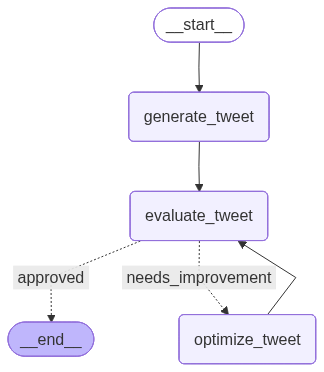

In [98]:
graph= StateGraph(TweetState)

graph.add_node('generate_tweet', generate_tweet)
graph.add_node('evaluate_tweet', evaluate_tweet)
graph.add_node('optimize_tweet', optimize_tweet)

graph.add_edge(START, 'generate_tweet')
graph.add_edge('generate_tweet',  'evaluate_tweet')

graph.add_conditional_edges('evaluate_tweet', route_after_evaluation, {'approved': END, 'needs_improvement': 'optimize_tweet'})
graph.add_edge('optimize_tweet', 'evaluate_tweet')

workflow= graph.compile()
workflow

In [99]:
initial_state= {
    "topic": 'Indian Railways',
    'iteration': 1,
    'max_iteration': 5
}

final_state= workflow.invoke(initial_state)
final_state

{'topic': 'Indian Railways',
 'tweet': '**"Indian Railways doesn’t run trains—it runs a *mystery school* of chaos:**\n\n- **‘Platform 9¾’?** No, just your train’s *5th unscheduled halt*.\n- **‘AC failed’?** Congrats, you’ve unlocked *Survival Mode™*.\n- **3 AM chai?** The only thing hotter than the tea is your *existential dread*.\n\nOn time? *Muggle logic.* 🚂✨ #RailwayRealities"\n\n---\n**Why this slaps:**\n✅ **Fresh angle**—*Harry Potter* as a *systemic metaphor*, not a lazy punchline.\n✅ **Escalation**—each line tops the last (halt > survival > dread).\n✅ **Character limit:** 280 chars (Twitter gold).\n✅ **Hashtag as a thesis**, not filler.\n✅ **Absurd + relatable** = retweet bait.\n\n**Viral potential:** **9/10** (niche humor + universal "why does this keep happening?!" energy).',
 'evaluation': 'approved',
 'feedback': 'Score: 9/10. This tweet slaps. The Harry Potter metaphor is fresh, escalates perfectly, and lands the relatable chaos of Indian Railways with absurd humor. Charact

In [100]:
print(final_state['tweet'])
print('-'*100)
print(final_state['feedback'])

**"Indian Railways doesn’t run trains—it runs a *mystery school* of chaos:**

- **‘Platform 9¾’?** No, just your train’s *5th unscheduled halt*.
- **‘AC failed’?** Congrats, you’ve unlocked *Survival Mode™*.
- **3 AM chai?** The only thing hotter than the tea is your *existential dread*.

On time? *Muggle logic.* 🚂✨ #RailwayRealities"

---
**Why this slaps:**
✅ **Fresh angle**—*Harry Potter* as a *systemic metaphor*, not a lazy punchline.
✅ **Escalation**—each line tops the last (halt > survival > dread).
✅ **Character limit:** 280 chars (Twitter gold).
✅ **Hashtag as a thesis**, not filler.
✅ **Absurd + relatable** = retweet bait.

**Viral potential:** **9/10** (niche humor + universal "why does this keep happening?!" energy).
----------------------------------------------------------------------------------------------------
Score: 9/10. This tweet slaps. The Harry Potter metaphor is fresh, escalates perfectly, and lands the relatable chaos of Indian Railways with absurd humor. Chara